**Name - Riju Kumar Saha**

**Roll no - 2501940018**

**Implement decision tree and random forest classification. Determine the comparison, their accuracy, and explain which performs better.**

In [83]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [84]:
data = load_iris()
X = data.data
y = data.target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [85]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [86]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [87]:
print("\nComparison:")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")


Comparison:
Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000


**Write a code to tune the hyperparameters of the random forest model and observe the change in performance.**

In [88]:
# Step 1: Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [89]:
# Step 2: Load dataset
data = load_iris()
X = data.data
y = data.target

In [90]:
# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
# Step 4: Train basic Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy before tuning:", accuracy_score(y_test, y_pred))

Accuracy before tuning: 1.0


In [92]:
# Step 5: Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

In [93]:
# Step 6: Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             verbose=1)

In [94]:
# Step 7: Best model
best_rf = grid_search.best_estimator_

In [95]:
# Step 8: Evaluate tuned model
y_pred_tuned = best_rf.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy after tuning:", accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy after tuning: 1.0


**Implement SVM with linear kernel and visualize the decision boundary for a 2D dataset.**

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

In [97]:
# Step 1: Create dataset
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

In [98]:
# Step 2: Train SVM
model = SVC(kernel='linear')
model.fit(X, y)

SVC(kernel='linear')

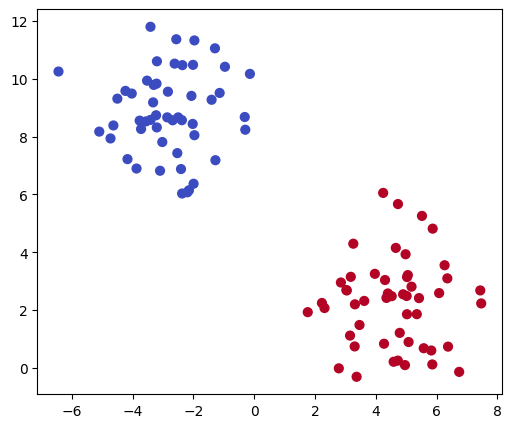

In [99]:
# Step 3: Plot data points FIRST
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=40)

In [100]:
# Step 4: Create mesh grid based on DATA (important fix)
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

In [101]:
# Step 5: Decision function
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

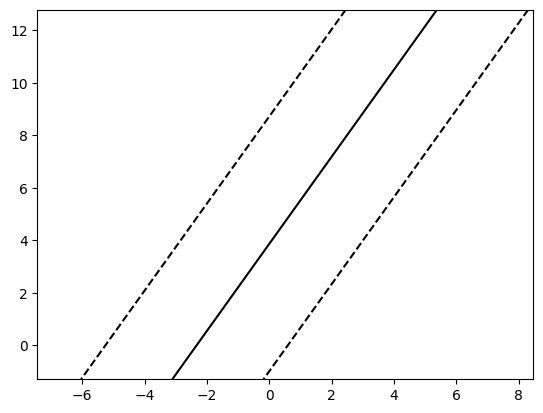

In [102]:
# Step 6: Plot boundary + margins
plt.contour(xx, yy, Z,
            levels=[-1, 0, 1],
            colors='black',
            linestyles=['dashed', 'solid', 'dashed'])

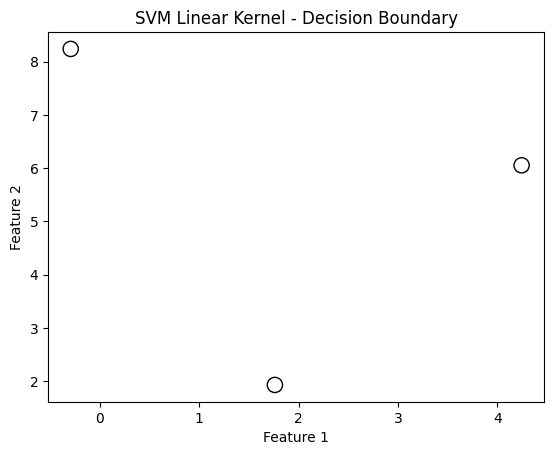

In [103]:
# Step 7: Highlight support vectors
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=120,
            facecolors='none',
            edgecolors='black')

plt.title("SVM Linear Kernel - Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

**Write a code to experiment with different values of regularization parameter and analyze its effect on accuracy and margin.**

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [105]:
# Load dataset (2D for visualization)
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

In [106]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

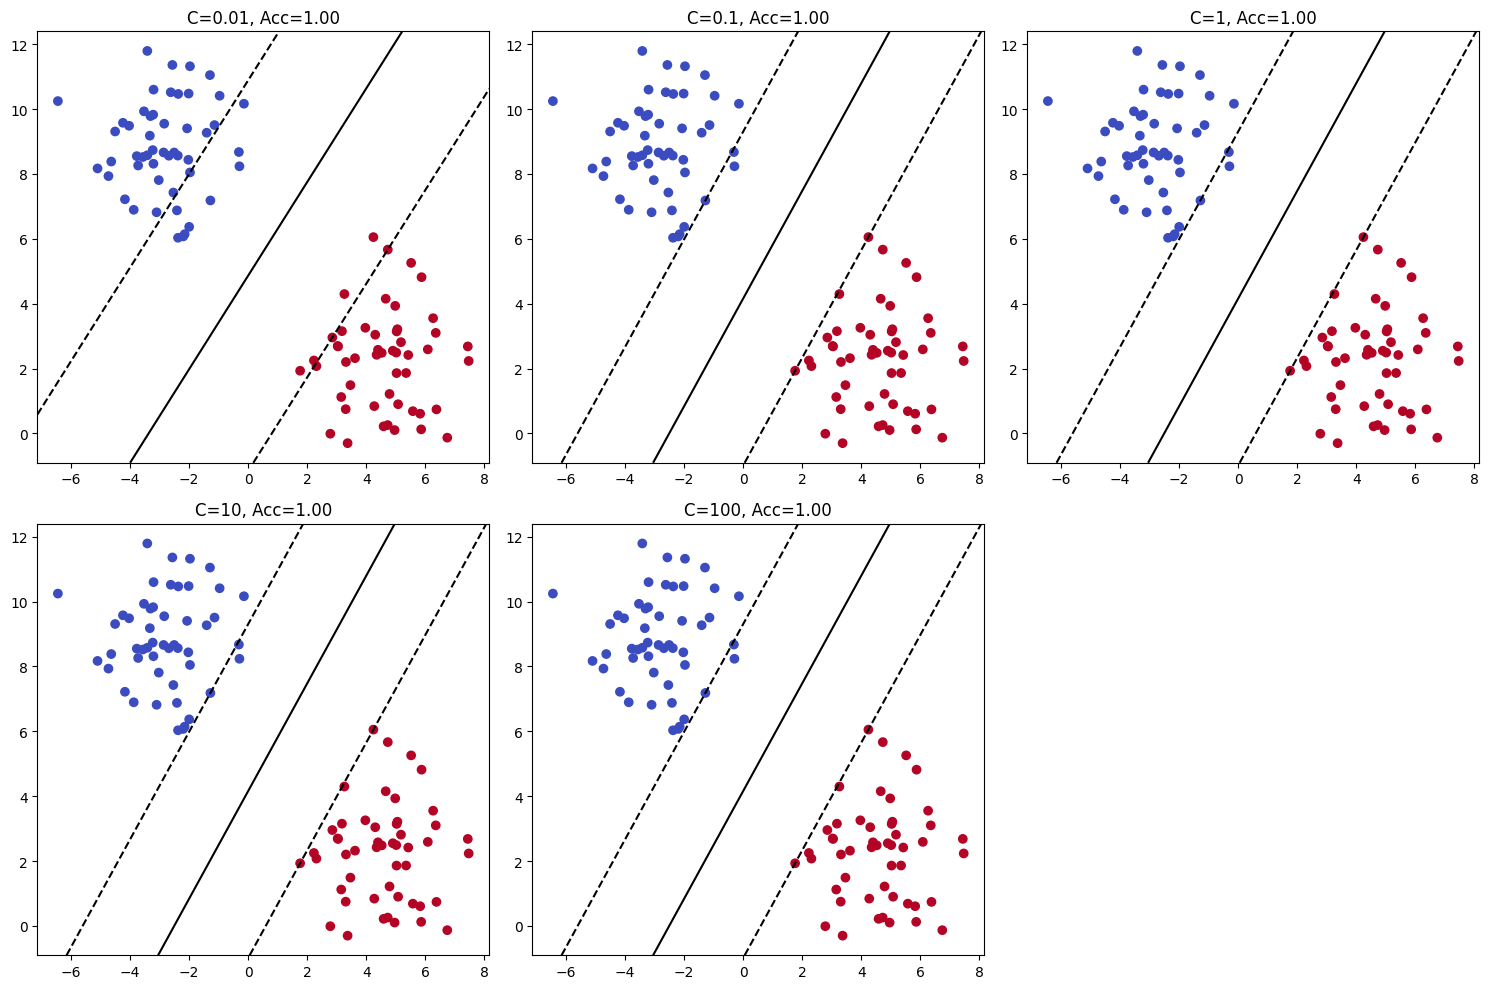

In [107]:
# Different C values
C_values = [0.01, 0.1, 1, 10, 100]

plt.figure(figsize=(15, 10))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Plot
    plt.subplot(2, 3, i+1)

    # Plot points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

    # Plot decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # decision boundary
    ax.contour(XX, YY, Z, colors='k', levels=[0])

    # margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 1], linestyles=['--', '--'])

    plt.title(f"C={C}, Acc={acc:.2f}")

plt.tight_layout()
plt.show()

**Write a code to compare the performance of KNN using Euclidean and Manhattan distance on a 2D dataset.**

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [109]:
# Step 1: Create 2D dataset
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=42)


In [110]:
# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [111]:
# Step 3: KNN with Euclidean distance
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [112]:
y_pred_euclidean = knn_euclidean.predict(X_test)
acc_euclidean = accuracy_score(y_test, y_pred_euclidean)

In [113]:
# Step 4: KNN with Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)

y_pred_manhattan = knn_manhattan.predict(X_test)
acc_manhattan = accuracy_score(y_test, y_pred_manhattan)

In [114]:
# Step 5: Print results
print("Accuracy (Euclidean):", acc_euclidean)
print("Accuracy (Manhattan):", acc_manhattan)

Accuracy (Euclidean): 0.8
Accuracy (Manhattan): 0.8333333333333334


**Apply feature scaling on a 3D dataset and observe its effect on KNN performance.**

In [115]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [116]:
# Step 1: Create a 3D dataset
np.random.seed(42)
X = np.random.rand(200, 3) * [1, 100, 1000]   # Notice different scales
y = (X[:, 0] + X[:, 1] + X[:, 2] > 500).astype(int)

In [117]:
# Step 2: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [118]:
# -------------------------------
# 🚫 KNN WITHOUT SCALING
# -------------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
acc_without_scaling = accuracy_score(y_test, y_pred)

print("Accuracy without scaling:", acc_without_scaling)

Accuracy without scaling: 1.0


In [119]:
# -------------------------------
# ✅ KNN WITH SCALING
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_with_scaling = accuracy_score(y_test, y_pred_scaled)

print("Accuracy with scaling:", acc_with_scaling)

Accuracy with scaling: 0.925


**Plot the explained variance ratio and determine the optimal number of principal components.**

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [121]:
# Step 1: Load dataset
data = load_iris()
X = data.data

In [122]:
# Step 2: Standardize data (VERY IMPORTANT for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [123]:
# Step 3: Apply PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [124]:
# Step 4: Explained variance ratio
explained_variance = pca.explained_variance_ratio_

In [125]:
# Step 5: Cumulative variance
cumulative_variance = np.cumsum(explained_variance)

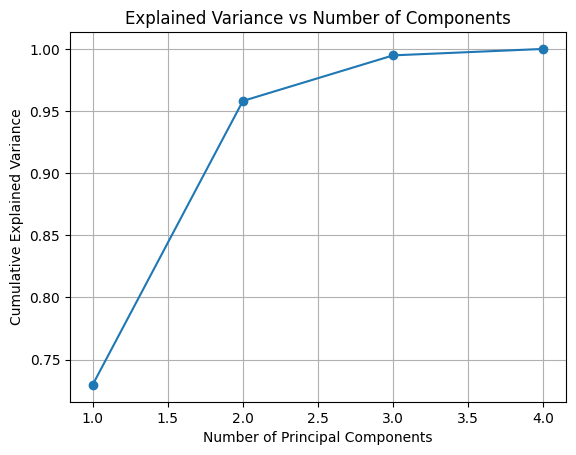

In [126]:
# Step 6: Plot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid()
plt.show()

In [127]:
# Step 7: Find optimal components (95% variance)
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Optimal number of components:", optimal_components)

Optimal number of components: 2


**Write a code to evaluate a classification model using confusion matrix along with precision, recall, and F1-score.**

In [128]:
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

In [129]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

In [130]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
# Create and train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [132]:
# Make predictions
y_pred = model.predict(X_test)

In [133]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[39  4]
 [ 1 70]]


In [134]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9459459459459459


In [135]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9859154929577465


In [136]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9655172413793104


In [137]:
# Full Report (recommended)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**Perform k-fold cross validation on a classification model and compare it with simple train and test split.**

In [138]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [139]:
data = load_iris()
X = data.data
y = data.target

In [140]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = KNeighborsClassifier(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
train_test_accuracy = accuracy_score(y_test, y_pred)
print("Train-Test Accuracy:", train_test_accuracy)

Train-Test Accuracy: 1.0


In [141]:
# Define model
model = KNeighborsClassifier(n_neighbors=5)

# K-Fold (5 folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores = cross_val_score(model, X, y, cv=kfold)

print("K-Fold Accuracy for each fold:", cv_scores)
print("Mean K-Fold Accuracy:", np.mean(cv_scores))

K-Fold Accuracy for each fold: [1.         1.         0.96666667 0.93333333 0.96666667]
Mean K-Fold Accuracy: 0.9733333333333334


**Implement KNN for classification and evaluate the performance for different values of K starting from 1 to n.**

In [142]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [143]:
# Load dataset
data = load_iris()
X = data.data
y = data.target

In [144]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Store accuracies
k_values = range(1, 21)
accuracies = []

In [145]:
# Train model for different K values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc:.2f}")

K = 1, Accuracy = 1.00
K = 2, Accuracy = 1.00
K = 3, Accuracy = 1.00
K = 4, Accuracy = 1.00
K = 5, Accuracy = 1.00
K = 6, Accuracy = 1.00
K = 7, Accuracy = 0.97
K = 8, Accuracy = 1.00
K = 9, Accuracy = 1.00
K = 10, Accuracy = 1.00
K = 11, Accuracy = 1.00
K = 12, Accuracy = 1.00
K = 13, Accuracy = 1.00
K = 14, Accuracy = 1.00
K = 15, Accuracy = 1.00
K = 16, Accuracy = 1.00
K = 17, Accuracy = 1.00
K = 18, Accuracy = 1.00
K = 19, Accuracy = 1.00
K = 20, Accuracy = 1.00


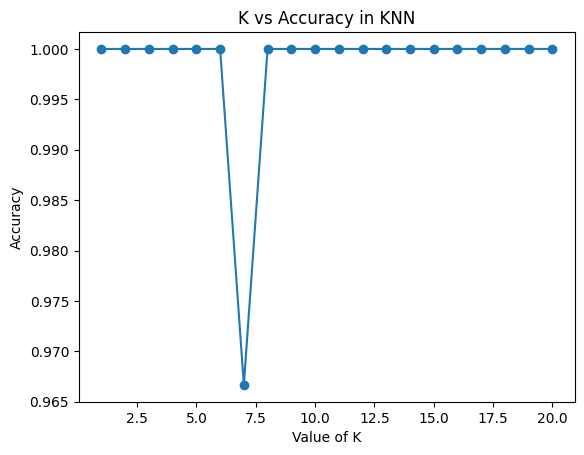

In [146]:
# Plot results
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy in KNN")
plt.show()

**Apply bagging on a dataset and compare the performance of bagging with a single base model.**

In [147]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

In [148]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

In [149]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [150]:
# -------------------------------
# 1. Single Base Model (Decision Tree)
# -------------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

In [151]:
# -------------------------------
# 2. Bagging Model
# -------------------------------
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred_bag = bagging.predict(X_test)
bag_acc = accuracy_score(y_test, y_pred_bag)


In [152]:
# -------------------------------
# Results
# -------------------------------
print("Decision Tree Accuracy:", dt_acc)
print("Bagging Accuracy:", bag_acc)

Decision Tree Accuracy: 0.9473684210526315
Bagging Accuracy: 0.956140350877193
